

**Clasificacion de Datos**

**Ing. Marcelo Saavedra**

**Ejemplo**

"Resolver el Problema de los Lirios de Fisher mediante Nayve Bayes"

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import numpy as np
import math

# Cargar la base de datos Iris
iris = load_iris()

# Acceder a los datos y etiquetas
X1 = iris.data  # Características (atributos)
y = iris.target  # Etiquetas (clases)

# P1 Imprimir los primeros 5 datos y etiquetas de cada clase
print("Primeros 5 datos:")
print(X1[0:5:,2:4])
print("Etiquetas correspondientes:")
print(y[40:105])


Primeros 5 datos:
[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]
Etiquetas correspondientes:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2]


***Graficando los Train***

Text(0.5, 1.0, 'Datos Train en 2 dimensiones con colores')

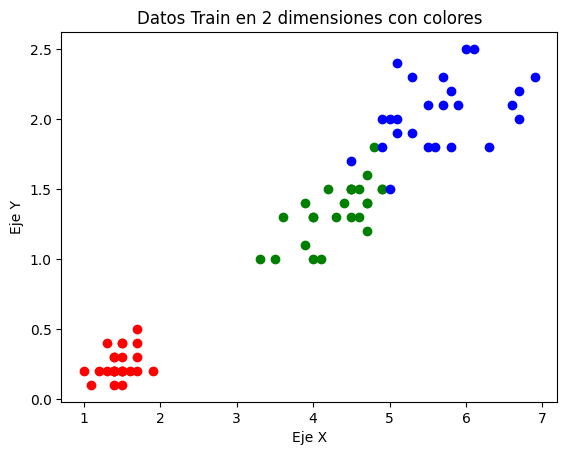

In [ ]:
# Graficar los puntos
plt.scatter(X1[0:25,2], X1[0:25,3], c='r')
plt.scatter(X1[50:75,2], X1[50:75,3], c='g')
plt.scatter(X1[100:125,2], X1[100:125,3], c='b')
# Configurar los ejes y el título del gráfico
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Datos Train en 2 dimensiones con colores')


***Graficando los Test***

Text(0.5, 1.0, 'Puntos en 2 dimensiones con colores')

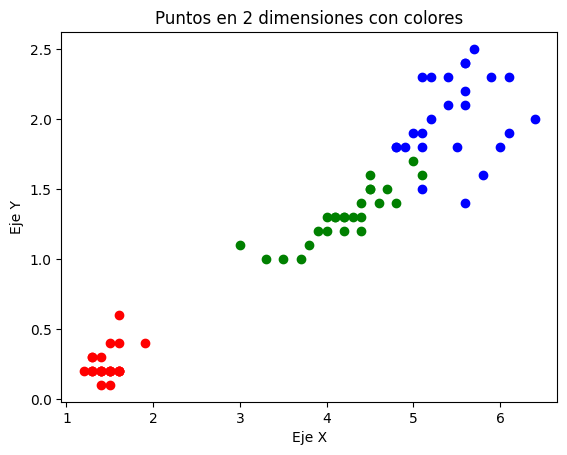

In [ ]:
# Graficar los puntos
plt.scatter(X1[25:50,2], X1[25:50,3], c='r')
plt.scatter(X1[75:100,2], X1[75:100,3], c='g')
plt.scatter(X1[125:150,2], X1[125:150,3], c='b')
# Configurar los ejes y el título del gráfico
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.title('Puntos en 2 dimensiones con colores')

***PARA LAS SETOSAS***

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_setosa = X1[0:25,2:4]
Y_train_setosa = y[0:25]
X_test_setosa= X1[25:50,2:4]  # Características (atributos)
Y_test_setosa= y[25:50]  # Etiquetas (clases)
# Imprimir los tamaños de los conjuntos de datos
print("Tamaño del conjunto de entrenamiento (train):", X_train_setosa.shape)
print("Tamaño del conjunto de prueba (test):", Y_train_setosa.shape)
# Imprimir los primeros 5 datos y etiquetas
print(Y_test_setosa)

Tamaño del conjunto de entrenamiento (train): (25, 2)
Tamaño del conjunto de prueba (test): (25,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


**Para las Versicolor**

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_versi = X1[50:75,2:4]
Y_train_versi = y[50:75]
X_test_versi= X1[75:100,2:4]  # Características (atributos)
Y_test_versi= y[75:100]  # Etiquetas (clases)
# Imprimir los tamaños de los conjuntos de datos
print("Tamaño del conjunto de entrenamiento (train):", X_train_versi.shape)
print("Tamaño del conjunto de prueba (test):", Y_train_versi.shape)

# Imprimir los primeros 5 datos y etiquetas
print(Y_test_versi)

Tamaño del conjunto de entrenamiento (train): (25, 2)
Tamaño del conjunto de prueba (test): (25,)
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


***Para las Virginicas***

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_virgi = X1[100:125,2:4]
Y_train_virgi = y[100:125]
X_test_virgi= X1[125:150,2:4]  # Características (atributos)
Y_test_virgi= y[125:150]  # Etiquetas (clases)
# Imprimir los tamaños de los conjuntos de datos
print("Tamaño del conjunto de entrenamiento (train):", X_train_virgi.shape)
print("Tamaño del conjunto de prueba (test):", Y_train_virgi.shape)

print(Y_test_virgi)

Tamaño del conjunto de entrenamiento (train): (25, 2)
Tamaño del conjunto de prueba (test): (25,)
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


Modelo Gaussiano a Realizar:

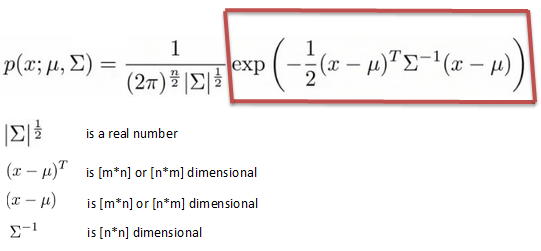

https://stackoverflow.com/questions/26611816/multivariate-gaussian-distribution-formula-implementation

***Operaciones Matematicas con los Train (entrenamiento?) ***

In [ ]:
print("---------- Para las Setosas: -------------------")

u_set = np.mean(X_train_setosa, axis=0) # Media de Setosas
print("La Media es: ",u_set)

cov_set = np.diag(np.diag(np.cov(X_train_setosa, rowvar=False))) # Covarianza Setosas
print("La Covarianza es: ",cov_set)

inv_cov_set = np.linalg.inv(cov_set)  # Inversa de la covarianza Setosa
print("La Inversa de la cov es: ",inv_cov_set)

det_cov_set = np.linalg.det(cov_set) # Determinante de la covarianza Setosa
print("El Determinante es: ",det_cov_set)

# print("---------- Para las Versicolor: -------------------")

# # Media de Versicolor
u_versi = np.mean(X_train_versi, axis=0)
cov_versi = np.diag(np.diag(np.cov(X_train_versi, rowvar=False))) # Covarianza Versicolor
inv_cov_versi = np.linalg.inv(cov_versi) # Inversa de la covarianza Versicolor
det_cov_versi = np.linalg.det(cov_versi) # Determinante de la covarianza Versicolor

print("Media_versi:", u_versi)
print( "Cov_versi: \n", cov_versi)
print("Inv Cov_versi: \n", inv_cov_versi)
print("Det Cov_versi:", det_cov_versi)

# print("---------- Para las Virginicas: -------------------")
# # Media de Virginica
u_virgi = np.mean(X_train_virgi, axis=0)
# # Covarianza Virginica
cov_virgi = np.diag(np.diag(np.cov(X_train_virgi, rowvar=False)))
# # Inversa de la covarianza Virginica
inv_cov_virgi = np.linalg.inv(cov_virgi)
# # Determinante de la covarianza Virginica
det_cov_virgi = np.linalg.det(cov_virgi)

print("Media_virgi:", u_virgi)
print( "Cov_virgi: \n", cov_virgi)
print("Inv Cov_virgi: \n", inv_cov_virgi)
print("Det Cov_virgi:", det_cov_virgi)


---------- Para las Setosas: -------------------
La Media es:  [1.46  0.248]
La Covarianza es:  [[0.03916667 0.        ]
 [0.         0.01093333]]
La Inversa de la cov es:  [[25.53191489  0.        ]
 [ 0.         91.46341463]]
El Determinante es:  0.0004282222222222222
Media_versi: [4.312 1.344]
Cov_versi: 
 [[0.19693333 0.        ]
 [0.         0.04256667]]
Inv Cov_versi: 
 [[ 5.07786053  0.        ]
 [ 0.         23.49256069]]
Det Cov_versi: 0.008382795555555555
Media_virgi: [5.64  2.044]
Cov_virgi: 
 [[0.4175     0.        ]
 [0.         0.06506667]]
Inv Cov_virgi: 
 [[ 2.39520958  0.        ]
 [ 0.         15.36885246]]
Det Cov_virgi: 0.02716533333333332


**Graficando las Gausianas**

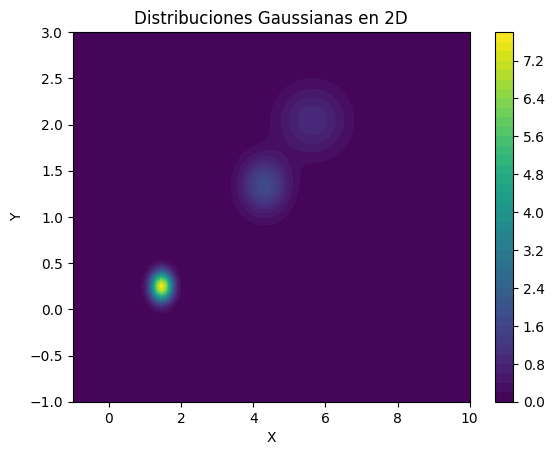

In [ ]:
from scipy.stats import multivariate_normal

# Parámetros de la primera distribución gaussiana

# Crear una cuadrícula de puntos en el plano XY
x, y = np.meshgrid(np.linspace(-1, 10, 100), np.linspace(-1, 3, 100))
pos = np.dstack((x, y))

# Calcular los valores de la primera distribución gaussiana en cada punto de la cuadrícula
gaussian = multivariate_normal(u_set, cov_set)
z = gaussian.pdf(pos)

# Parámetros de la segunda distribución gaussiana
# Calcular los valores de la segunda distribución gaussiana en cada punto de la cuadrícula
gaussian1 = multivariate_normal(u_versi, cov_versi)
z1 = gaussian1.pdf(pos)

# Calcular los valores de la segunda distribución gaussiana en cada punto de la cuadrícula
gaussian2 = multivariate_normal(u_virgi, cov_virgi)
z2 = gaussian2.pdf(pos)

# Sumar los valores de ambas distribuciones para combinarlas
combined_z = z + z1 + z2

# Graficar ambas distribuciones en un solo gráfico
plt.contourf(x, y, combined_z, levels=50, cmap='viridis')
plt.colorbar()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Distribuciones Gaussianas en 2D')
plt.show()

***Resultados con los Test***

In [ ]:
# Juntando los datos test en un solo vector
X_Test_total = np.concatenate((X_test_setosa, X_test_versi, X_test_virgi), axis=0)
Y_Test_total = np.concatenate((Y_test_setosa, Y_test_versi, Y_test_virgi), axis=0)
#print(X_Test_total)
print(Y_Test_total)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2]


In [ ]:
# Recorriendo los índices
Y_result=np.zeros(75)

for i in range(len(X_Test_total)):
    #print(i)
    #print(X_Test_total[i])
    # Calcular la fórmula de la gaussiana
    x=X_Test_total[i]
    diff_set = x - u_set
    exponent_set = -0.5 * np.dot(np.dot(diff_set, inv_cov_set), diff_set.T)
    #print(exponent_set)
    denominator_set = (2 * math.pi) * math.sqrt(det_cov_set)

    gaussian_set = (1 / denominator_set) * math.exp(exponent_set)
    #print(gaussian_set)
    diff_versi = x - u_versi
    exponent_versi = -0.5 * np.dot(np.dot(diff_versi, inv_cov_versi), diff_versi.T)
    denominator_versi = (2 * math.pi) * math.sqrt(det_cov_versi)
    gaussian_versi = (1 / denominator_versi) * math.exp(exponent_versi)
    #print(gaussian_versi)
    diff_virgi = x - u_virgi
    exponent_virgi = -0.5 * np.dot(np.dot(diff_virgi, inv_cov_virgi), diff_virgi.T)
    denominator_virgi = (2 * math.pi) * math.sqrt(det_cov_virgi)
    gaussian_virgi = (1 / denominator_virgi) * math.exp(exponent_virgi)
    #print(gaussian_virgi)

    if gaussian_set>gaussian_versi and gaussian_set>gaussian_virgi:
      Y_result[i]=0
    elif gaussian_versi>gaussian_set and gaussian_versi>gaussian_virgi:
      Y_result[i]=1
    elif gaussian_virgi>gaussian_set and gaussian_virgi>gaussian_versi:
      Y_result[i]=2

print(Y_Test_total)
print(Y_result)

#Y_Test_total+Y_result

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 2. 2. 2. 2. 2. 2. 2. 2. 1. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2.]


Matriz de confusión:
[[25  0  0]
 [ 0 24  1]
 [ 0  1 24]]


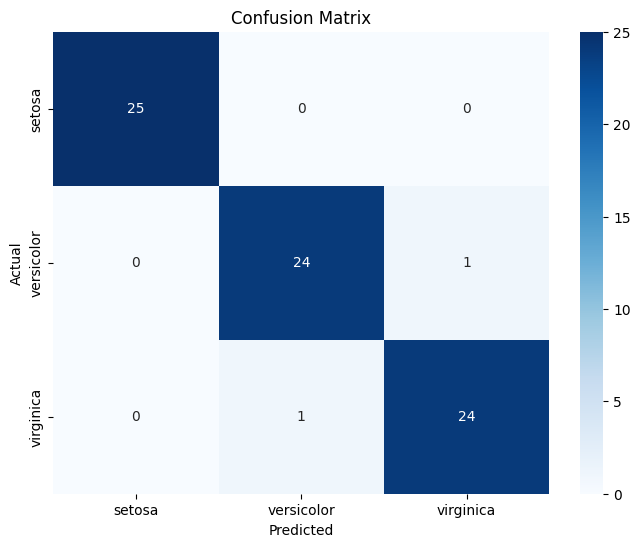

In [ ]:
import seaborn as sns

# Construir la matriz de confusión
confusion = confusion_matrix(Y_Test_total, Y_result)
# Imprimir la matriz de confusión
print("Matriz de confusión:")
print(confusion)

# Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, cmap='Blues', fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Calculando curva ROC entre Versicolor y Virginica
vp=0
fp=0
vn=0
fn=0
vpr1 = 0
fpr1 = 0

tpr = [0] * 50
fpr = [0]* 50


for i in range(25, 75):
    tpr[i-25]=vpr1
    fpr[i-25]=fpr1
    if Y_result[i] == 1 and Y_Test_total[i] == 1:
        vp += 1
    if Y_result[i] == 2 and Y_Test_total[i] == 2:
        vn += 1
    if Y_result[i] == 2 and Y_Test_total[i] == 1:
        fp += 1
    if Y_result[i] == 1 and Y_Test_total[i] == 2:
        fn += 1
    #print(f"VP: {vp}, FP: {fp}, FN: {fn}, VN: {vn}")

    if (vp + fn)!=0:
      vpr1 = vp/(vp + fn)


    if (fp + vn)!=0:
      fpr1 = fp/(fp + vn)


fpr=np.round(fpr, 2)


tpr = np.sort(tpr)
fpr = np.sort(fpr)


In [ ]:
 print(tpr)
 print(fpr)

[0.   0.96 0.96 0.96 0.96 0.96 0.96 0.96 0.96 0.96 0.96 0.96 0.96 0.96
 0.96 0.96 0.96 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.  ]
[0.   0.   0.   0.04 0.04 0.05 0.05 0.05 0.05 0.06 0.06 0.06 0.07 0.07
 0.08 0.08 0.09 0.1  0.11 0.11 0.12 0.14 0.17 0.2  0.25 0.33 0.5  1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.  ]


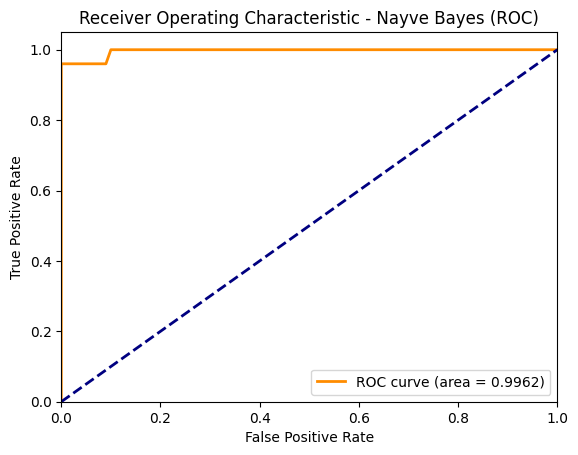

In [ ]:
# Graficando curva ROC entre Versicolor y Virginica
from sklearn.metrics import roc_curve, auc

roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Nayve Bayes (ROC)')
plt.legend(loc="lower right")
plt.show()